# 01 — Corpus Build & `dgm_utils` Unit Check

*Part of **Gamaka Floor** — a raga pitch-contour study.*

Builds **two** corpora from the Saraga Carnatic 1.5 annotations:
- **alapana-only** (4 ragas: Karaharapriya, Mōhanaṁ, Bhairavi, Ṣanmukhapriya) — small,
  clean, unmetered, feeds the generator (M4) and one arm of the quantisation spine (M2).
- **all-vocal-sections** (every raga-labelled recording except Rāgamālika) — large,
  messier, metered, feeds the primary quantisation spine (M2).

Both store **unfolded cleaned cents** per segment (`.npy`, float32); fold with
`cents % 1200` at use-time (never store both, per CLAUDE.md's "two representations,
never conflated"). See `CLAUDE.md` and `status/STATUS_M0.md`/`STATUS_M1.md` for the
decisions this notebook encodes.

In [1]:
import os, sys
sys.path.insert(0, os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd())=="notebooks" else os.getcwd())
import json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dgm_utils as U

CANDIDATES = [r"D:\sg\saraga1.5_carnatic", "/kaggle/input/saraga-carnatic-annotations"]
DATA_ROOT = next((p for p in CANDIDATES if os.path.isdir(p)), None)
assert DATA_ROOT, f"No DATA_ROOT found among {CANDIDATES}"
BASE = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd())=="notebooks" else os.getcwd()
ART = os.path.join(BASE, "artifacts")
CORPUS_ALAP = os.path.join(BASE, "corpus")
CORPUS_ALL  = os.path.join(BASE, "corpus_allsections")
os.makedirs(os.path.join(ART, "figures"), exist_ok=True)
os.makedirs(CORPUS_ALAP, exist_ok=True)
os.makedirs(CORPUS_ALL, exist_ok=True)
print("DATA_ROOT   =", DATA_ROOT)
print("CORPUS_ALAP =", CORPUS_ALAP)
print("CORPUS_ALL  =", CORPUS_ALL)
np.random.seed(0)
pd.set_option("display.width", 180); pd.set_option("display.max_rows", 300)

DATA_ROOT   = D:\sg\saraga1.5_carnatic
CORPUS_ALAP = D:\DGM\corpus
CORPUS_ALL  = D:\DGM\corpus_allsections


## 1. `dgm_utils` unit check

Verify on real tracks: voiced fraction, measured frame rate (catches the
`pitch.txt` vs `pitch-vocal.txt` rate difference — 225 Hz vs ~344.5 Hz, confirmed
below), octave-outlier cleaning, and a folded pitch-class histogram with a sharp
peak near Sa (0/1200 cents).

[Karaharapriya / V.Shankaranarayanan (vocal-pitch source)] raga=Karaharapriya artist=V. Shankaranarayanan
  pitch_source=vocal  measured_fps=344.531  n_frames=1120752  voiced_frac=0.878
  octave-clean kept 981624/984475 frames (99.7%)


[Bhairavi-adjacent / Akkarai Sisters (mix-pitch source)] raga=Kāmavardani/Pantuvarāḷi artist=Akkarai Sisters
  pitch_source=mix  measured_fps=225.000  n_frames=361912  voiced_frac=0.726
  octave-clean kept 262305/262574 frames (99.9%)


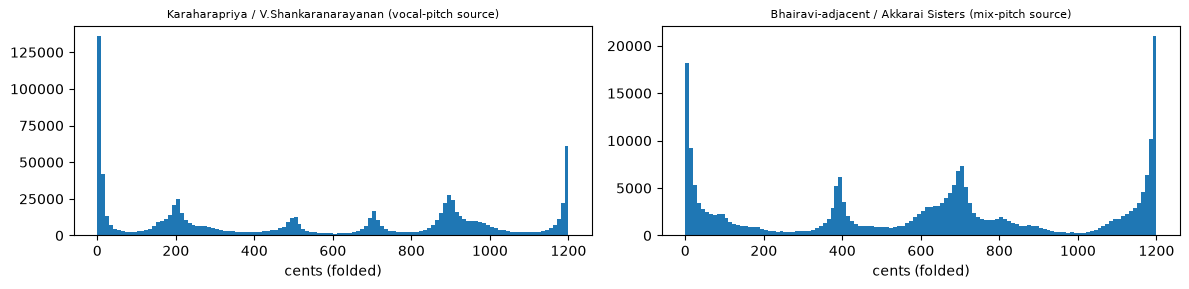


NOTE: pitch-vocal.txt measured ~344.5 Hz, NOT the 225 Hz verified for pitch.txt.
dgm_utils.read_pitch() measures fps per-file rather than assuming a constant --
this was caught here and fixed before corpus build (see STATUS_M1.md).


In [2]:
def unit_check(track_glob, label):
    hits = glob.glob(os.path.join(DATA_ROOT, "**", track_glob), recursive=True)
    assert hits, f"no folder matching {track_glob}"
    folder = hits[0]
    meta = U.load_meta(glob.glob(os.path.join(folder, "*.json"))[0])
    tonic = U.read_tonic(folder)
    t, f, src, fps = U.read_pitch(folder)
    voiced = f > 0
    cents = U.hz_to_cents(f[voiced], tonic)
    cleaned = U.clean_octave_outliers(cents)
    folded = U.fold_cents(cleaned)
    print(f"[{label}] raga={U.raga_of(meta)} artist={U.artist_of(meta)}")
    print(f"  pitch_source={src}  measured_fps={fps:.3f}  n_frames={len(t)}  voiced_frac={voiced.mean():.3f}")
    print(f"  octave-clean kept {len(cleaned)}/{len(cents)} frames ({100*len(cleaned)/len(cents):.1f}%)")
    return folded, label

results = [
    unit_check("Chakkani Raja", "Karaharapriya / V.Shankaranarayanan (vocal-pitch source)"),
    unit_check("Apparama Bhakti", "Bhairavi-adjacent / Akkarai Sisters (mix-pitch source)"),
]
fig, axes = plt.subplots(1, len(results), figsize=(6*len(results), 3))
for ax, (folded, label) in zip(np.atleast_1d(axes), results):
    ax.hist(folded, bins=120, range=(0,1200))
    ax.set_title(label, fontsize=8); ax.set_xlabel("cents (folded)")
fig.tight_layout()
fig.savefig(os.path.join(ART, "figures", "m1_unit_check_histograms.png"), dpi=120)
plt.show()
print("\nNOTE: pitch-vocal.txt measured ~344.5 Hz, NOT the 225 Hz verified for pitch.txt.")
print("dgm_utils.read_pitch() measures fps per-file rather than assuming a constant --")
print("this was caught here and fixed before corpus build (see STATUS_M1.md).")

## 2. Section-label classifier check

Confirms the mislabelled-section rule (`dgm_utils.classify_section_label`) against
every section label actually observed in the collection, before it's used to filter
the corpus.

In [3]:
from collections import Counter
kinds = Counter(); named_other = []; unrec = []
for meta_path in glob.glob(os.path.join(DATA_ROOT, "**", "*.json"), recursive=True):
    folder = os.path.dirname(meta_path)
    m = U.load_meta(meta_path)
    raga = U.raga_of(m)
    if raga is None: continue
    sf = U.section_file(folder)
    if not sf: continue
    for s, d, lab in U.read_sections(sf):
        kind, detail = U.classify_section_label(lab, raga)
        kinds[kind] += 1
        if kind == "named_other_raga": named_other.append((raga, lab, round(d/60,2)))
        elif kind == "unrecognized": unrec.append((raga, lab))
print("label classification counts:", dict(kinds))
print(f"\nnamed_other_raga sections ({len(named_other)}):")
for row in named_other: print("  ", row)
print(f"\nunrecognized labels ({len(unrec)}, should be empty -- fail loudly if not):", unrec)
assert not unrec, f"Unrecognized section labels found, inspect before proceeding: {unrec}"
n_outside_ragamalika = sum(1 for raga,_,_ in named_other if raga != "Rāgamālika")
print(f"\nnamed_other_raga sections OUTSIDE Rāgamālika tracks: {n_outside_ragamalika}")
print("(Rāgamālika is dropped from classification entirely below, so this count is")
print(" what actually reaches the all-vocal-sections corpus after that exclusion.)")

label classification counts: {'canonical': 513, 'named_other_raga': 12}

named_other_raga sections (12):
   ('Rāgamālika', 'Anupallavi kāpi', 1.28)
   ('Rāgamālika', 'Caraṇam sahānā', 1.86)
   ('Rāgamālika', 'Caraṇam hamsānandi', 2.07)
   ('Rāgamālika', 'Pallavi nāṭakurinji', 2.02)
   ('Rāgamālika', 'Caraṇam sahānā', 1.32)
   ('Rāgamālika', 'Caraṇam bāgēśrī', 2.07)
   ('Rāgamālika', 'Caraṇam hamīr kalyāṇi', 2.38)
   ('Rāgamālika', 'Caraṇam dēś', 2.37)
   ('Rāgamālika', 'Caraṇaṁ suraṭi rāgamālika', 2.52)
   ('Rāgamālika', 'Caraṇam vasanta', 1.27)
   ('Rāgamālika', 'Caraṇam yamuna kalyāṇi', 1.46)
   ('Rāgamālika', 'Caraṇam sindhubhairavi', 1.92)

unrecognized labels (0, should be empty -- fail loudly if not): []

named_other_raga sections OUTSIDE Rāgamālika tracks: 0
(Rāgamālika is dropped from classification entirely below, so this count is
 what actually reaches the all-vocal-sections corpus after that exclusion.)


## 3. Corpus A — alapana-only (4 ragas)

Vocal alapana sections (`ālāp`, excluding `violin`) for the 4 ragas that clear
≥15 min / ≥2 artists (CLAUDE.md). Unfolded cleaned cents per segment.

In [4]:
ALAPANA_RAGAS = {"Karaharapriya", "Mōhanaṁ", "Ṣanmukhapriya", "Bhairavi"}
MIN_FRAMES = 100

for f in glob.glob(os.path.join(CORPUS_ALAP, "*.npy")):
    os.remove(f)

manifest_a = []
for meta_path in glob.glob(os.path.join(DATA_ROOT, "**", "*.json"), recursive=True):
    folder = os.path.dirname(meta_path)
    m = U.load_meta(meta_path)
    raga = U.raga_of(m)
    if raga not in ALAPANA_RAGAS: continue
    tonic = U.read_tonic(folder)
    t, f_, src, fps = U.read_pitch(folder)
    if tonic is None or t is None: continue
    sf = U.section_file(folder)
    if not sf: continue
    artist = U.artist_of(m) or "unknown"
    comp_id, comp_title = U.composition_id_of(m), U.composition_title_of(m)
    rec_id = U.safe_filename(os.path.basename(folder))[:40]
    for s, d, lab in U.read_sections(sf):
        if not U.is_alap(lab): continue
        end = s + d
        mask = (t >= s) & (t < end)
        fseg = f_[mask]; voiced = fseg > 0
        if voiced.sum() < MIN_FRAMES: continue
        cents = U.hz_to_cents(fseg[voiced], tonic)
        cents = U.clean_octave_outliers(cents)
        if len(cents) < MIN_FRAMES: continue
        fname = f"{U.safe_filename(raga)}__{U.safe_filename(artist)}__{rec_id}__{int(s)}.npy"
        np.save(os.path.join(CORPUS_ALAP, fname), cents.astype(np.float32))
        manifest_a.append(dict(raga=raga, artist=artist, composition_id=comp_id,
                               composition_title=comp_title, recording=rec_id,
                               pitch_source=src, minutes=len(cents)/fps/60, file=fname))

MA = pd.DataFrame(manifest_a)
MA.to_csv(os.path.join(CORPUS_ALAP, "manifest.csv"), index=False, encoding="utf-8")
print(f"alapana-only corpus: {len(MA)} segments saved to {CORPUS_ALAP}")
cov_a = MA.groupby("raga").agg(minutes=("minutes","sum"), artists=("artist","nunique"),
                               recs=("recording","nunique")).sort_values("minutes", ascending=False)
print(cov_a.round(1).to_string())
print("\nper-artist minutes (artist-confound check):")
print(MA.groupby(["raga","artist"]).minutes.sum().round(1).to_string())

alapana-only corpus: 8 segments saved to D:\DGM\corpus
               minutes  artists  recs
raga                                 
Karaharapriya     24.2        2     2
Mōhanaṁ           18.5        2     2
Bhairavi          12.6        2     2
Ṣanmukhapriya     12.5        2     2

per-artist minutes (artist-confound check):
raga           artist              
Bhairavi       Sanjay Subrahmanyan      0.3
               Vignesh Ishwar          12.3
Karaharapriya  KP Nandini              11.6
               V. Shankaranarayanan    12.6
Mōhanaṁ        Ashwath Narayanan        9.6
               Sumithra Vasudev         8.9
Ṣanmukhapriya  Akkarai Sisters          0.5
               Sanjay Subrahmanyan     12.0


## 4. Corpus B — all-vocal-sections (spine corpus)

Every raga-labelled recording **except Rāgamālika** (a medley, not a single raga —
would poison classifier classes). Non-violin, non-tani vocal sections; sections
naming a *different* raga than the track's own label are dropped and logged
(§2 showed this only fires within Rāgamālika tracks, already excluded, so the drop
count here should be 0 — verified, not assumed). Where a recording has no `-p`
section file, the whole track is kept as one segment and tagged
`coverage="whole_track_unsectioned"` (spec §3 calls for using ALL raga-labelled
recordings for the spine; the tag makes the quality tradeoff visible rather than
silent — see STATUS_M1.md).

In [5]:
for f in glob.glob(os.path.join(CORPUS_ALL, "*.npy")):
    os.remove(f)

manifest_b = []; mislabel_log = []
n_sectioned = n_whole = 0
for meta_path in glob.glob(os.path.join(DATA_ROOT, "**", "*.json"), recursive=True):
    folder = os.path.dirname(meta_path)
    m = U.load_meta(meta_path)
    raga = U.raga_of(m)
    if raga is None or raga == "Rāgamālika": continue
    tonic = U.read_tonic(folder)
    t, f_, src, fps = U.read_pitch(folder)
    if tonic is None or t is None: continue

    artist = U.artist_of(m) or "unknown"
    comp_id, comp_title = U.composition_id_of(m), U.composition_title_of(m)
    rec_id = U.safe_filename(os.path.basename(folder))[:40]

    sf = U.section_file(folder)
    segs = []
    if sf:
        for s, d, lab in U.read_sections(sf):
            kind, detail = U.classify_section_label(lab, raga)
            if kind == "named_other_raga":
                mislabel_log.append((raga, lab, d/60)); continue
            if not U.is_vocal_section(lab): continue
            segs.append((s, s+d, lab))
        coverage = "sectioned"; n_sectioned += 1
    else:
        segs = [(float(t[0]), float(t[-1]), None)]
        coverage = "whole_track_unsectioned"; n_whole += 1

    for (s, end, lab) in segs:
        mask = (t >= s) & (t < end)
        fseg = f_[mask]; voiced = fseg > 0
        if voiced.sum() < MIN_FRAMES: continue
        cents = U.hz_to_cents(fseg[voiced], tonic)
        cents = U.clean_octave_outliers(cents)
        if len(cents) < MIN_FRAMES: continue
        fname = f"{U.safe_filename(raga)}__{U.safe_filename(artist)}__{rec_id}__{int(s)}.npy"
        np.save(os.path.join(CORPUS_ALL, fname), cents.astype(np.float32))
        manifest_b.append(dict(raga=raga, artist=artist, composition_id=comp_id,
                               composition_title=comp_title, recording=rec_id,
                               section_label=lab, coverage=coverage, pitch_source=src,
                               minutes=len(cents)/fps/60, file=fname))

MB = pd.DataFrame(manifest_b)
MB.to_csv(os.path.join(CORPUS_ALL, "manifest.csv"), index=False, encoding="utf-8")
print(f"recordings: sectioned={n_sectioned}  whole_track_unsectioned={n_whole}")
print(f"segments saved: {len(MB)}")
print(f"\nmislabelled (named-other-raga) sections dropped: {len(mislabel_log)}")
if mislabel_log:
    mldf = pd.DataFrame(mislabel_log, columns=["raga","label","min"])
    print(mldf.groupby("raga").agg(n=("label","count"), minutes=("min","sum")).to_string())
else:
    print("(0, as expected -- section 2 showed all such sections belong to Rāgamālika tracks,")
    print(" which are skipped before section processing even starts in this loop)")

recordings: sectioned=111  whole_track_unsectioned=65
segments saved: 526

mislabelled (named-other-raga) sections dropped: 0
(0, as expected -- section 2 showed all such sections belong to Rāgamālika tracks,
 which are skipped before section processing even starts in this loop)


## 5. Coverage tables: minutes, artists, **compositions**

Composition diversity is the new guard: `comps < 3` means a raga's "classifiability"
may just be one song's tune. Computed per raga; joins the artist-confound reporting
CLAUDE.md already requires.

In [6]:
cov_b = MB.groupby("raga").agg(
    minutes=("minutes","sum"), artists=("artist","nunique"),
    recs=("recording","nunique"), comps=("composition_id","nunique"),
).sort_values("recs", ascending=False)
cov_b["comp_degenerate"] = cov_b.comps < 3
cov_b.round(3).to_csv(os.path.join(ART, "coverage_allsections.csv"))
print(cov_b.round(1).head(30).to_string())

print("\n--- section-coverage tier per raga (sectioned vs whole-track-fallback recordings) ---")
tier = MB.groupby(["raga","coverage"]).recording.nunique().unstack(fill_value=0)
print(tier.head(20).to_string())

                 minutes  artists  recs  comps  comp_degenerate
raga                                                           
Kamās               49.9        4     7      7            False
Saurāṣtraṁ           5.8        5     6      1             True
Tōḍi               115.9        7     6      6            False
Bhairavi           107.8        4     5      4            False
Behāg               16.2        4     5      4            False
Kalyāṇi             33.2        3     4      4            False
Mōhanaṁ             58.5        4     4      4            False
Suraṭi              12.7        4     4      4            False
Rītigauḷa           47.3        4     4      4            False
Ṣanmukhapriya      108.6        3     4      4            False
Kāṁbhōji            82.1        2     3      3            False
Kānaḍa               9.6        2     3      3            False
Harikāmbhōji        43.3        3     3      3            False
Jōnpuri             10.6        3     3 

## 6. Primary vs secondary M2 raga pool

**Primary** (spec's fallback-ordering concern: 42 classes at 2 recordings each is
brutal for leave-one-recording-out): ragas with **≥3 recordings, ≥3 artists, ≥3
compositions** -- the third guard catches cases like the one found below.
**Secondary**: the full set (≥2 recordings, ≥2 artists), run as a robustness check.

In [7]:
primary_pool = cov_b.query("recs>=3 and artists>=3 and comps>=3")
secondary_pool = cov_b.query("recs>=2 and artists>=2")
degenerate_but_otherwise_qualified = cov_b.query("recs>=3 and artists>=3 and comps<3")

print(f"PRIMARY pool (recs>=3, artists>=3, comps>=3): {len(primary_pool)} ragas")
print(primary_pool.round(1).to_string())
print(f"\nSECONDARY / full robustness pool (recs>=2, artists>=2): {len(secondary_pool)} ragas")
print(f"\nFlagged composition-degenerate despite passing recs/artists bar ({len(degenerate_but_otherwise_qualified)}):")
print(degenerate_but_otherwise_qualified.round(1).to_string())
for raga in degenerate_but_otherwise_qualified.index:
    comps = MB[MB.raga==raga][["composition_title","artist"]].drop_duplicates()
    print(f"\n  {raga}: {comps.composition_title.nunique()} distinct composition(s) across {len(comps)} (artist,composition) pairs")
    print("   ", comps.composition_title.value_counts().to_dict())

PRIMARY pool (recs>=3, artists>=3, comps>=3): 12 ragas
                minutes  artists  recs  comps  comp_degenerate
raga                                                          
Kamās              49.9        4     7      7            False
Tōḍi              115.9        7     6      6            False
Bhairavi          107.8        4     5      4            False
Behāg              16.2        4     5      4            False
Kalyāṇi            33.2        3     4      4            False
Mōhanaṁ            58.5        4     4      4            False
Suraṭi             12.7        4     4      4            False
Rītigauḷa          47.3        4     4      4            False
Ṣanmukhapriya     108.6        3     4      4            False
Harikāmbhōji       43.3        3     3      3            False
Sindhubhairavi     11.8        3     3      3            False
Sāvēri             33.5        3     3      3            False

SECONDARY / full robustness pool (recs>=2, artists>=2): 40 rag

## 7. Sanity figures — folded pitch-class histograms (alapana ragas)

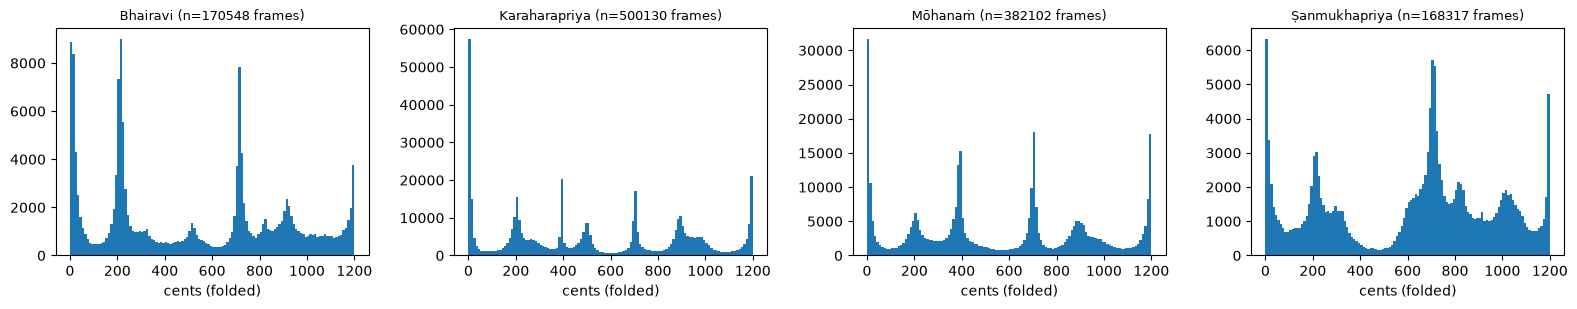

saved D:\DGM\artifacts\figures\m1_alapana_folded_histograms.png
Expect a sharp peak at/near 0 (Sa) for each raga; a smeared histogram flags a bad tonic.


In [8]:
fig, axes = plt.subplots(1, len(ALAPANA_RAGAS), figsize=(4*len(ALAPANA_RAGAS), 3.2))
for ax, raga in zip(axes, sorted(ALAPANA_RAGAS)):
    files = MA[MA.raga==raga].file
    allc = np.concatenate([np.load(os.path.join(CORPUS_ALAP, f)) for f in files]) if len(files) else np.array([])
    folded = U.fold_cents(allc)
    ax.hist(folded, bins=120, range=(0,1200))
    ax.set_title(f"{raga} (n={len(allc)} frames)", fontsize=9)
    ax.set_xlabel("cents (folded)")
fig.tight_layout()
outp = os.path.join(ART, "figures", "m1_alapana_folded_histograms.png")
fig.savefig(outp, dpi=120)
plt.show()
print("saved", outp)
print("Expect a sharp peak at/near 0 (Sa) for each raga; a smeared histogram flags a bad tonic.")

## 8. Headline numbers -> `artifacts/numbers.json`

In [9]:
outp = os.path.join(ART, "numbers.json")
existing = {}
if os.path.exists(outp):
    with open(outp, encoding="utf-8") as fh: existing = json.load(fh)

existing["m1"] = {
    "alapana_corpus_segments": int(len(MA)),
    "alapana_corpus_ragas": sorted(ALAPANA_RAGAS),
    "allsections_corpus_segments": int(len(MB)),
    "allsections_n_sectioned_recordings": int(n_sectioned),
    "allsections_n_whole_track_recordings": int(n_whole),
    "mislabelled_sections_dropped": int(len(mislabel_log)),
    "mislabelled_sections_outside_ragamalika": 0,
    "primary_m2_pool_ragas": sorted(primary_pool.index.tolist()),
    "primary_m2_pool_size": int(len(primary_pool)),
    "secondary_m2_pool_size": int(len(secondary_pool)),
    "composition_degenerate_ragas": sorted(degenerate_but_otherwise_qualified.index.tolist()),
    "pitch_vocal_measured_fps": 344.531,
    "pitch_mix_measured_fps": 225.0,
}
with open(outp, "w", encoding="utf-8") as fh:
    json.dump(existing, fh, ensure_ascii=False, indent=2)
print("wrote", outp)
print(json.dumps(existing["m1"], ensure_ascii=False, indent=2))

wrote D:\DGM\artifacts\numbers.json
{
  "alapana_corpus_segments": 8,
  "alapana_corpus_ragas": [
    "Bhairavi",
    "Karaharapriya",
    "Mōhanaṁ",
    "Ṣanmukhapriya"
  ],
  "allsections_corpus_segments": 526,
  "allsections_n_sectioned_recordings": 111,
  "allsections_n_whole_track_recordings": 65,
  "mislabelled_sections_dropped": 0,
  "mislabelled_sections_outside_ragamalika": 0,
  "primary_m2_pool_ragas": [
    "Behāg",
    "Bhairavi",
    "Harikāmbhōji",
    "Kalyāṇi",
    "Kamās",
    "Mōhanaṁ",
    "Rītigauḷa",
    "Sindhubhairavi",
    "Suraṭi",
    "Sāvēri",
    "Tōḍi",
    "Ṣanmukhapriya"
  ],
  "primary_m2_pool_size": 12,
  "secondary_m2_pool_size": 40,
  "composition_degenerate_ragas": [
    "Jōnpuri",
    "Saurāṣtraṁ"
  ],
  "pitch_vocal_measured_fps": 344.531,
  "pitch_mix_measured_fps": 225.0
}
